# 05 — Explainability

This project uses synthetic data inspired by common online gaming analytics use cases. It does not contain confidential or proprietary Junglee Games data.

Global bars are mean absolute contributions from the champion. A positive local contribution pushed that player's score toward churn. Contributions explain the score. They are not an estimate of what happens if a product manager changes the feature.


In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import os
os.chdir(ROOT)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Project root:", ROOT)


Project root: /workspace/player-churn-prediction


**Method.** SHAP TreeExplainer on RandomForestClassifier (80 trees). Class-1 contributions; one-hot columns summed back to the original feature. Computed on all 71,164 June holdout rows.

### Mean absolute contribution

,feature,label,mean_abs_shap,mean_shap
0,days_since_last_game,Days since last game,0.0995,0.0298
1,days_since_last_login,Days since last login,0.0517,0.0073
2,games_7d,Games in the last 7 days,0.0375,-0.0011
3,active_days_7d,Active days in the last 7 days,0.0338,0.0053
4,rake_7d,Rake in the last 7 days,0.0338,-0.0016
5,sessions_7d,Sessions in the last 7 days,0.0230,0.0002
6,games_change_14d_vs_previous_14d,Change in games versus the prior two weeks,0.0177,0.0049
7,days_since_last_withdrawal,Days since last withdrawal,0.0161,-0.0084
8,days_since_last_deposit,Days since last deposit,0.0138,0.0004
9,inactivity_gap_days,Longest inactivity gap in 30 days,0.0117,-0.0033


### Permutation importance (drop in holdout PR-AUC)

,feature,label,mean_importance,std_importance
0,days_since_last_game,Days since last game,0.0188,0.0022
1,games_change_14d_vs_previous_14d,Change in games versus the prior two weeks,0.0129,0.0008
2,rake_7d,Rake in the last 7 days,0.0126,0.0016
3,days_since_last_deposit,Days since last deposit,0.0115,0.0022
4,active_days_7d,Active days in the last 7 days,0.0105,0.0046
5,deposit_decline_flag,Deposit-decline flag,0.0080,0.0025
6,days_since_last_login,Days since last login,0.0080,0.0032
7,deposit_change_7d_vs_previous_7d,Change in deposits versus the prior week,0.0049,0.0039
8,games_30d,Games in the last 30 days,0.0047,0.0012
9,total_entry_fee,Total entry fees in the last 30 days,0.0040,0.0015


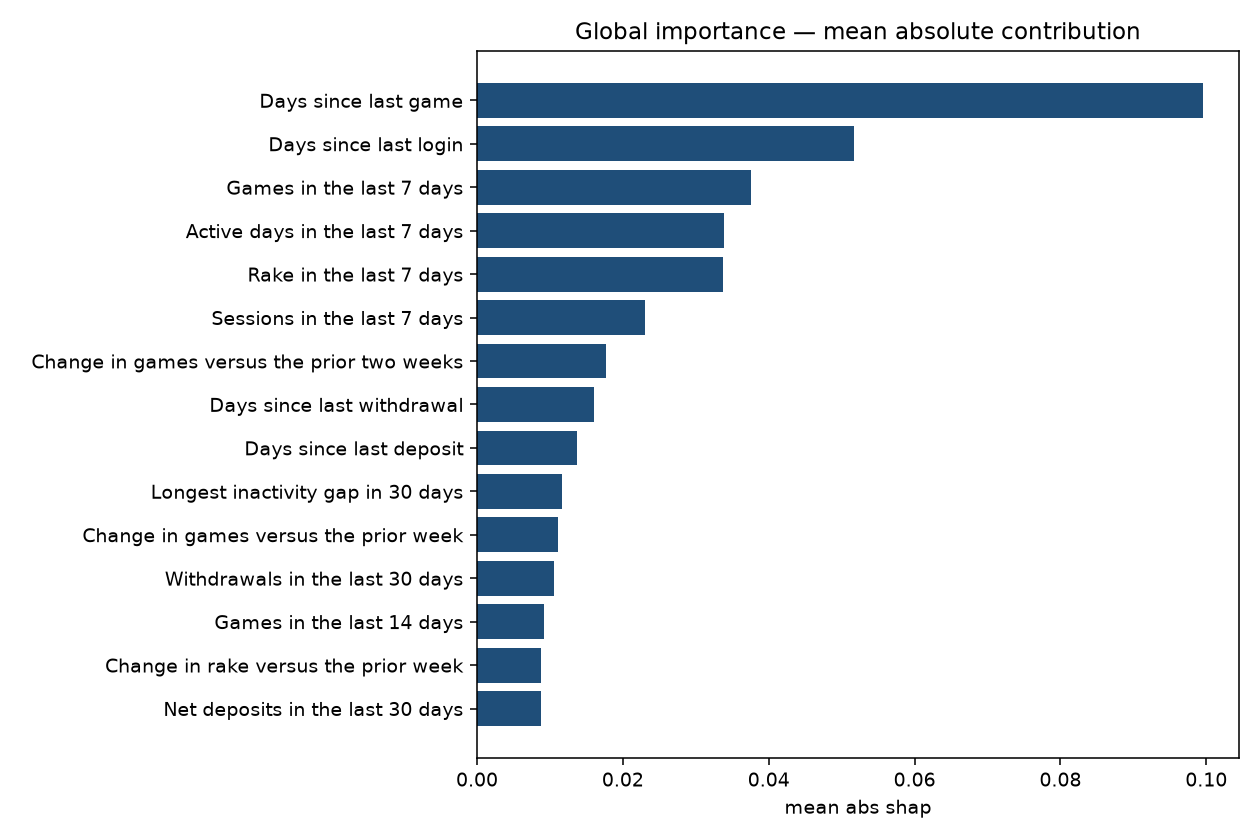

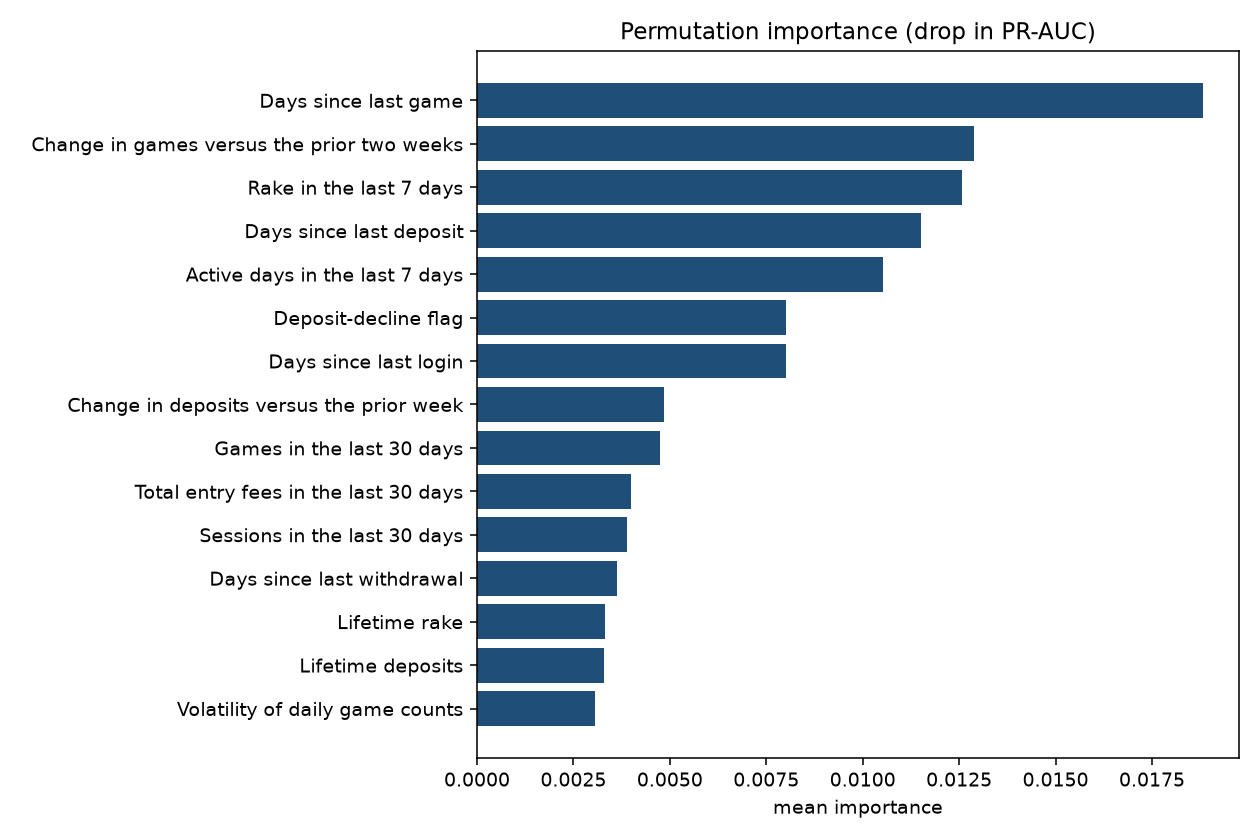

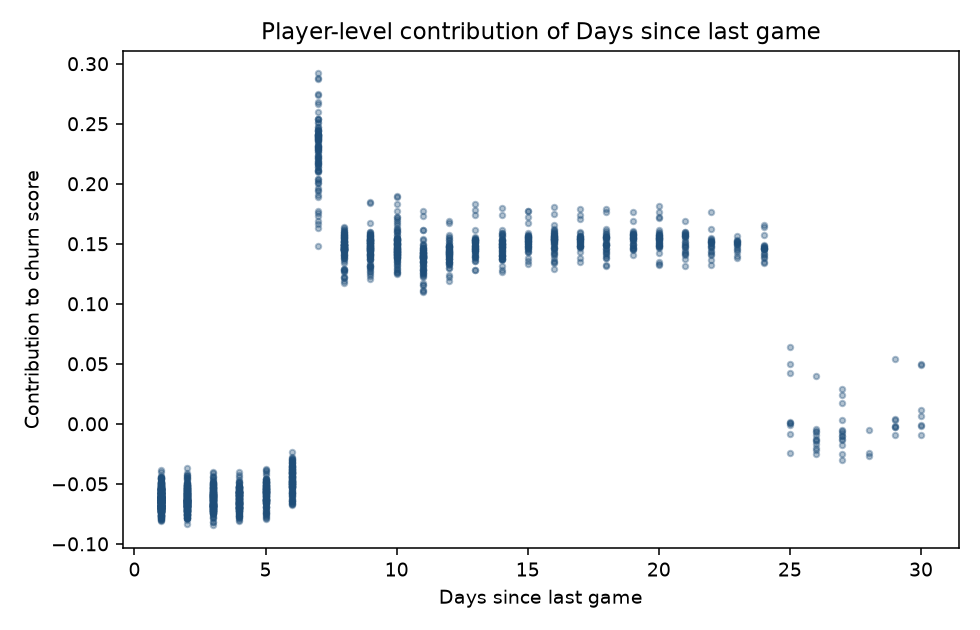

The strongest average contributor is **Days since last game** (mean absolute contribution 0.0995). Read the dependence chart as 'how this feature moves the score in this model,' not as 'shortening recency by a day will save this many players.'

In [2]:
summary = json.loads((ROOT / "reports/model_metrics/explain_summary.json").read_text())
importance = pd.read_csv(ROOT / "reports/model_metrics/shap_importance.csv")
permutation = pd.read_csv(ROOT / "reports/model_metrics/permutation_importance.csv")
display(Markdown(f"**Method.** {summary['method']}"))
display(Markdown("### Mean absolute contribution"))
display(importance.head(12))
display(Markdown("### Permutation importance (drop in holdout PR-AUC)"))
display(permutation.head(12))
from IPython.display import Image
display(Image(filename=str(ROOT / "reports/figures/shap_importance.png")))
display(Image(filename=str(ROOT / "reports/figures/permutation_importance.png")))
display(Image(filename=str(ROOT / "reports/figures/shap_dependence_top_feature.png")))
top = importance.iloc[0]
display(Markdown(
    f"The strongest average contributor is **{top['label']}** "
    f"(mean absolute contribution {top['mean_abs_shap']:.4f}). "
    "Read the dependence chart as 'how this feature moves the score in this model,' "
    "not as 'shortening recency by a day will save this many players.'"
))


In [3]:
scores = pd.read_csv(ROOT / "reports/scores/player_risk_scores.csv")
examples = scores.nlargest(3, "churn_probability")[
    ["user_id", "churn_probability", "risk_band", "segment",
     "top_risk_driver_1", "top_risk_driver_2", "top_risk_driver_3",
     "days_since_last_game", "games_30d", "games_change_7d_vs_previous_7d",
     "active_days_30d", "deposit_amount_30d", "recommended_action"]
]
display(Markdown("### Three highest-scoring synthetic players"))
display(examples)
low = scores.nsmallest(1, "churn_probability")[
    ["user_id", "churn_probability", "risk_band", "days_since_last_game", "games_30d", "recommended_action"]
]
display(Markdown("### A low-score contrast"))
display(low)
display(Markdown(
    "Drivers are blank when the contribution did not increase risk. "
    "Do not fill that gap with a story the model did not support."
))


### Three highest-scoring synthetic players

,user_id,churn_probability,risk_band,segment,top_risk_driver_1,top_risk_driver_2,top_risk_driver_3,days_since_last_game,games_30d,games_change_7d_vs_previous_7d,active_days_30d,deposit_amount_30d,recommended_action
0,10026328,0.9804,CRITICAL,Dormant/Reactivation,Days since last game,Days since last login,Games in the last 7 days,18,25,0.0000,5,221.0800,Urgent — Engagement journey
1,10084019,0.9804,CRITICAL,Dormant/Reactivation,Days since last game,Days since last login,Games in the last 7 days,20,22,0.0000,4,191.9300,Urgent — Engagement journey
2,10010965,0.9803,CRITICAL,Dormant/Reactivation,Days since last game,Days since last login,Games in the last 7 days,16,27,0.0000,7,631.7000,Urgent — Engagement journey


### A low-score contrast

,user_id,churn_probability,risk_band,days_since_last_game,games_30d,recommended_action
71163,10000313,0.0474,LOW,1,5,Normal lifecycle engagement


Drivers are blank when the contribution did not increase risk. Do not fill that gap with a story the model did not support.